# TFM - Clasificación de frutas con Deep Learning

## Pipeline Deep Learning con ResNet50 sobre dataset completo

En este notebook se desarrolla un segundo enfoque para la clasificación de frutas, basado en Deep Learning mediante ResNet50 y transferencia de aprendizaje.

A diferencia del pipeline clásico de Machine Learning, donde se extraían manualmente características visuales como histograma RGB, HOG y LBP, en este enfoque el modelo aprende directamente patrones visuales a partir de las imágenes.

El pipeline seguirá la siguiente lógica técnica:

1. Carga de los archivos `train_dataset.csv` y `test_dataset.csv`.
2. Revisión de rutas, etiquetas y distribución de clases.
3. Preparación de las imágenes:

   * Redimensionado a 224x224 píxeles.
   * Conversión a array numérico.
   * Preprocesamiento compatible con ResNet50.
4. Creación de un generador de datos para cargar las imágenes por lotes.
5. Carga de ResNet50 preentrenada con ImageNet.
6. Adaptación de la capa final al número de clases del dataset de frutas.
7. Entrenamiento inicial con la base ResNet50 congelada.
8. Evaluación mediante:

   * Accuracy.
   * F1 macro.
   * Classification report.
   * Matriz de confusión.
9. Aplicación opcional de fine-tuning sobre las últimas capas del modelo.
10. Evaluación final y guardado de resultados.




## Bloque 1 - Importación de librerías

En este bloque se importan las librerías necesarias para desarrollar el pipeline de Deep Learning.

Se incluyen librerías generales para trabajar con datos y rutas, junto con TensorFlow/Keras, que se utilizará para cargar imágenes, crear el generador de datos y construir el modelo ResNet50.

In [3]:
pip install update
pip install tensorflow

SyntaxError: invalid syntax (2812809124.py, line 1)

In [1]:
# =========================
# BLOQUE 1: IMPORTACIÓN DE LIBRERÍAS
# =========================

# Librerías generales
import math
import numpy as np
import pandas as pd

from pathlib import Path

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras import callbacks

from sklearn.model_selection import train_test_split

## Bloque 2 - Configuración de rutas y parámetros

En este bloque se definen las rutas principales del proyecto y los parámetros generales que se utilizarán en el pipeline de Deep Learning.

Centralizar estas rutas y parámetros permite evitar duplicaciones en el código y facilita modificar la configuración del notebook si cambia la ubicación de los archivos o si se ajustan parámetros como el tamaño de imagen o el tamaño de lote.

In [5]:
# =========================
# BLOQUE 2: CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# =========================

# Definimos la ruta raíz del proyecto.
# Si el notebook se ejecuta desde la carpeta notebooks, subimos un nivel.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Definimos las carpetas principales del proyecto.
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SPLITS_DIR = DATA_DIR / "splits"

# Definimos las rutas de los archivos CSV de train y test.
TRAIN_CSV_PATH = SPLITS_DIR / "train_dataset.csv"
TEST_CSV_PATH = SPLITS_DIR / "test_dataset.csv"

# Parámetros generales para las imágenes.
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 6

# Ruta raíz donde se encuentran las imágenes.
# Esta ruta se revisará en los siguientes bloques según cómo estén escritas las rutas dentro del CSV.
IMAGE_ROOT = RAW_DIR / "archive"

## Bloque 3 - Comprobación de rutas

En este bloque se comprueba que las rutas principales definidas anteriormente existen correctamente.

Esta verificación es importante antes de cargar los CSV o las imágenes, ya que permite detectar errores de ubicación, nombres de carpetas o estructura del proyecto antes de avanzar en el pipeline.

In [7]:
# =========================
# BLOQUE 3: COMPROBACIÓN DE RUTAS
# =========================

# Creamos un diccionario con las rutas importantes del proyecto para este notebook.
# La clave es el nombre de la variable y el valor es la ruta correspondiente.
rutas_a_comprobar = {
    "PROJECT_DIR": PROJECT_DIR,
    "DATA_DIR": DATA_DIR,
    "RAW_DIR": RAW_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "SPLITS_DIR": SPLITS_DIR,
    "TRAIN_CSV_PATH": TRAIN_CSV_PATH,
    "TEST_CSV_PATH": TEST_CSV_PATH,
    "IMAGE_ROOT": IMAGE_ROOT
}

# Recorremos cada ruta y comprobamos si existe.
# ruta.exists() devuelve:
# True  -> la ruta existe
# False -> la ruta no existe o está mal definida
for nombre, ruta in rutas_a_comprobar.items():
    print(f"{nombre}: {ruta.exists()} -> {ruta}")

PROJECT_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/04_Deep_Learning
DATA_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/04_Deep_Learning/data
RAW_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/04_Deep_Learning/data/raw
PROCESSED_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/04_Deep_Learning/data/processed
SPLITS_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/04_Deep_Learning/data/splits
TRAIN_CSV_PATH: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión

## Bloque 4 - Carga de los archivos CSV

En este bloque se cargan los archivos `train_dataset.csv` y `test_dataset.csv`.

Estos archivos contienen la partición de datos que se utilizará en el enfoque de Deep Learning:

- `train_dataset.csv`: imágenes destinadas al entrenamiento del modelo.
- `test_dataset.csv`: imágenes reservadas para la evaluación final.

El conjunto de test no se utilizará durante el entrenamiento, para evitar que el modelo vea datos que después se usarán para medir su rendimiento.

In [5]:
pwd

'/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/scripts_y_resultados/creacion_de_modelos/Deep_Learning'

In [8]:
# =========================
# BLOQUE 4: CARGA DE LOS ARCHIVOS CSV
# =========================
TRAIN_CSV_PATH="train_dataset.csv"
TEST_CSV_PATH="test_dataset.csv"



# Cargamos los archivos CSV de entrenamiento y test.
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

# Mostramos el número de filas y columnas de cada conjunto.
print("Dimensiones train:", train_df.shape)
print("Dimensiones test:", test_df.shape)

Dimensiones train: (49384, 5)
Dimensiones test: (21165, 5)


## Bloque 5 - Revisión inicial de los CSV

En este bloque se revisa la estructura inicial de los archivos cargados.

El objetivo es comprobar qué columnas contiene cada CSV, visualizar las primeras filas y confirmar qué campos representan la ruta de la imagen y la etiqueta de clase.

Esta revisión es necesaria antes de crear el generador de imágenes, ya que el modelo necesitará saber de dónde cargar cada imagen y cuál es su clase correspondiente.

In [3]:
# =========================
# BLOQUE 5: REVISIÓN INICIAL DE LOS CSV
# =========================

# Mostramos las columnas disponibles en cada dataset.
print("Columnas train:")
print(train_df.columns.tolist())

print("\nColumnas test:")
print(test_df.columns.tolist())

# Visualizamos las primeras filas del conjunto de entrenamiento.
display(train_df.head())

# Visualizamos las primeras filas del conjunto de test.
display(test_df.head())

Columnas train:
['Unnamed: 0', '0', 'fruta', 'percent', 'label_encoded']

Columnas test:
['Unnamed: 0', '0', 'fruta', 'percent', 'label_encoded']


,Unnamed: 0,0,fruta,percent,label_encoded
0,7491,Apple/Total Number of Apples/Apple 01463.png,Apple,15.855197,0
1,55445,Peach/Peach0092.png,Peach,3.726382,7
2,48975,muskmelon/Muskmelon 00931.png,muskmelon,2.945387,14
3,27743,Guava/Guava total/Guava。2200 resized.png,Guava,27.921645,3
4,54259,Peach/Peach001990.png,Peach,3.726382,7


,Unnamed: 0,0,fruta,percent,label_encoded
0,65100,Plum/Plum。1595.png,Plum,3.257218,11
1,17521,Guava/guava total final/Guava03043.png,Guava,27.921645,3
2,9343,Apple/Total Number of Apples/Apple_0_6816.png,Apple,15.855197,0
3,34101,Guava/Guava total/1Guava。2817 resized.jpg,Guava,27.921645,3
4,64087,Plum/Plum。579.png,Plum,3.257218,11


## Bloque 6 - Renombrado de columnas

En este bloque se renombran algunas columnas de los CSV para que sean más claras y coherentes con el resto del proyecto.

La columna `0` contiene la ruta relativa de cada imagen, por lo que se renombra como `ruta_imagen`.

La columna `fruta` contiene el nombre de la clase, por lo que se renombra como `clase`.

La columna `label_encoded` contiene la clase codificada numéricamente, necesaria para entrenar el modelo.

También se elimina la columna `Unnamed: 0`, ya que corresponde a un índice guardado previamente en el CSV y no aporta información útil para el entrenamiento.

In [4]:
# =========================
# BLOQUE 6: RENOMBRADO DE COLUMNAS
# =========================

# Eliminamos la columna "Unnamed: 0" si existe.
# Esta columna corresponde a un índice guardado previamente en el CSV.
train_df = train_df.drop(columns=["Unnamed: 0"], errors="ignore")
test_df = test_df.drop(columns=["Unnamed: 0"], errors="ignore")

# Renombramos las columnas para hacerlas más claras y coherentes con el proyecto.
train_df = train_df.rename(columns={
    "0": "ruta_imagen",
    "fruta": "clase",
    "percent": "porcentaje_clase",
    "label_encoded": "clase_codificada"
})

test_df = test_df.rename(columns={
    "0": "ruta_imagen",
    "fruta": "clase",
    "percent": "porcentaje_clase",
    "label_encoded": "clase_codificada"
})

# Comprobamos el resultado final de las columnas.
print("Columnas train:")
print(train_df.columns.tolist())

print("\nColumnas test:")
print(test_df.columns.tolist())

Columnas train:
['ruta_imagen', 'clase', 'porcentaje_clase', 'clase_codificada']

Columnas test:
['ruta_imagen', 'clase', 'porcentaje_clase', 'clase_codificada']


## Bloque 7 - Comprobación de estructura final y valores nulos

En este bloque se revisa la estructura final de los DataFrames después del renombrado de columnas.

El objetivo es comprobar que las columnas tienen nombres claros, que no existen valores nulos y que los datos necesarios para entrenar el modelo están disponibles correctamente.

Esta revisión es importante antes de crear el generador de imágenes, ya que el modelo necesitará utilizar la ruta de cada imagen y su clase codificada.

In [5]:
# =========================
# BLOQUE 7: COMPROBACIÓN DE ESTRUCTURA FINAL Y VALORES NULOS
# =========================

# Mostramos las columnas finales de cada DataFrame.
print("Columnas finales train:")
print(train_df.columns.tolist())

print("\nColumnas finales test:")
print(test_df.columns.tolist())

# Comprobamos si existen valores nulos en train.
print("\nValores nulos en train:")
display(train_df.isnull().sum())

# Comprobamos si existen valores nulos en test.
print("\nValores nulos en test:")
display(test_df.isnull().sum())

# Visualizamos algunas filas para confirmar que la estructura es correcta.
display(train_df.head())
display(test_df.head())

Columnas finales train:
['ruta_imagen', 'clase', 'porcentaje_clase', 'clase_codificada']

Columnas finales test:
['ruta_imagen', 'clase', 'porcentaje_clase', 'clase_codificada']

Valores nulos en train:


ruta_imagen         0
clase               0
porcentaje_clase    0
clase_codificada    0
dtype: int64


Valores nulos en test:


ruta_imagen         0
clase               0
porcentaje_clase    0
clase_codificada    0
dtype: int64

,ruta_imagen,clase,porcentaje_clase,clase_codificada
0,Apple/Total Number of Apples/Apple 01463.png,Apple,15.855197,0
1,Peach/Peach0092.png,Peach,3.726382,7
2,muskmelon/Muskmelon 00931.png,muskmelon,2.945387,14
3,Guava/Guava total/Guava。2200 resized.png,Guava,27.921645,3
4,Peach/Peach001990.png,Peach,3.726382,7


,ruta_imagen,clase,porcentaje_clase,clase_codificada
0,Plum/Plum。1595.png,Plum,3.257218,11
1,Guava/guava total final/Guava03043.png,Guava,27.921645,3
2,Apple/Total Number of Apples/Apple_0_6816.png,Apple,15.855197,0
3,Guava/Guava total/1Guava。2817 resized.jpg,Guava,27.921645,3
4,Plum/Plum。579.png,Plum,3.257218,11


## Bloque 8 - Revisión de clases y distribución

En este bloque se revisa el número de clases disponibles y la distribución de imágenes por clase en los conjuntos de entrenamiento y test.

Esta comprobación permite verificar que las clases están correctamente representadas y que la partición 70/30 mantiene una distribución coherente entre ambos conjuntos.

In [6]:
# =========================
# BLOQUE 8: REVISIÓN DE CLASES Y DISTRIBUCIÓN
# =========================

# Calculamos el número de clases distintas en train y test.
num_clases_train = train_df["clase"].nunique()
num_clases_test = test_df["clase"].nunique()

print("Número de clases en train:", num_clases_train)
print("Número de clases en test:", num_clases_test)

# Revisamos las clases disponibles en cada conjunto.
clases_train = sorted(train_df["clase"].unique())
clases_test = sorted(test_df["clase"].unique())

print("\nClases en train:")
print(clases_train)

print("\nClases en test:")
print(clases_test)

# Comprobamos la distribución de imágenes por clase.
print("\nDistribución de clases en train:")
display(train_df["clase"].value_counts().sort_index())

print("\nDistribución de clases en test:")
display(test_df["clase"].value_counts().sort_index())

Número de clases en train: 15
Número de clases en test: 15

Clases en train:
['Apple', 'Banana', 'Carambola', 'Guava', 'Kiwi', 'Mango', 'Orange', 'Peach', 'Pear', 'Persimmon', 'Pitaya', 'Plum', 'Pomegranate', 'Tomatoes', 'muskmelon']

Clases en test:
['Apple', 'Banana', 'Carambola', 'Guava', 'Kiwi', 'Mango', 'Orange', 'Peach', 'Pear', 'Persimmon', 'Pitaya', 'Plum', 'Pomegranate', 'Tomatoes', 'muskmelon']

Distribución de clases en train:


clase
Apple           7829
Banana          2119
Carambola       1456
Guava          13789
Kiwi            5925
Mango           2908
Orange          2108
Peach           1840
Pear            2108
Persimmon       1450
Pitaya          1751
Plum            1609
Pomegranate     1517
Tomatoes        1520
muskmelon       1455
Name: count, dtype: int64


Distribución de clases en test:


clase
Apple          3356
Banana          908
Carambola       624
Guava          5909
Kiwi           2540
Mango          1246
Orange          904
Peach           789
Pear            904
Persimmon       622
Pitaya          750
Plum            689
Pomegranate     650
Tomatoes        651
muskmelon       623
Name: count, dtype: int64

## Bloque 9 - Comprobación de clases codificadas

En este bloque se revisa la relación entre el nombre de cada clase y su etiqueta numérica codificada.

El modelo de Deep Learning no entrenará directamente con el nombre textual de la fruta, sino con una etiqueta numérica asociada a cada clase.

Por este motivo, se comprueba que cada clase tenga una única codificación y que la correspondencia sea coherente en los conjuntos de entrenamiento y test.

In [7]:
# =========================
# BLOQUE 9: COMPROBACIÓN DE CLASES CODIFICADAS
# =========================

# Revisamos la correspondencia entre clase textual y clase codificada en train.
mapa_clases_train = (
    train_df[["clase", "clase_codificada"]]
    .drop_duplicates()
    .sort_values("clase_codificada")
)

# Revisamos la correspondencia entre clase textual y clase codificada en test.
mapa_clases_test = (
    test_df[["clase", "clase_codificada"]]
    .drop_duplicates()
    .sort_values("clase_codificada")
)

print("Correspondencia clase - clase_codificada en train:")
display(mapa_clases_train)

print("Correspondencia clase - clase_codificada en test:")
display(mapa_clases_test)

# Comprobamos cuántas clases distintas hay por cada código.
print("Número de clases por código en train:")
display(train_df.groupby("clase_codificada")["clase"].nunique())

print("Número de clases por código en test:")
display(test_df.groupby("clase_codificada")["clase"].nunique())

Correspondencia clase - clase_codificada en train:


,clase,clase_codificada
0,Apple,0
9,Banana,1
16,Carambola,2
3,Guava,3
19,Kiwi,4
11,Mango,5
66,Orange,6
1,Peach,7
59,Pear,8
52,Persimmon,9


Correspondencia clase - clase_codificada en test:


,clase,clase_codificada
2,Apple,0
12,Banana,1
432,Carambola,2
1,Guava,3
9,Kiwi,4
7,Mango,5
8,Orange,6
13,Peach,7
6,Pear,8
123,Persimmon,9


Número de clases por código en train:


clase_codificada
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
Name: clase, dtype: int64

Número de clases por código en test:


clase_codificada
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
Name: clase, dtype: int64

## Bloque 10A - Verificación de rutas de imágenes

En este bloque se comprueba que las rutas relativas almacenadas en el CSV permiten localizar correctamente las imágenes en disco.

Cada fila del DataFrame contiene una ruta relativa en la columna `ruta_imagen`. Para poder cargar la imagen, esta ruta se combina con la carpeta raíz de imágenes definida previamente.

Esta verificación es importante antes de crear el generador de datos, ya que si las rutas no son correctas el modelo no podrá cargar las imágenes durante el entrenamiento.

In [10]:
muestra_rutas

,ruta_imagen,clase,porcentaje_clase,clase_codificada,ruta_completa
0,Apple/Total Number of Apples/Apple 01463.png,Apple,15.855197,0,../../data/raw/archive/Apple/Total Number of A...
1,Peach/Peach0092.png,Peach,3.726382,7,../../data/raw/archive/Peach/Peach0092.png
2,muskmelon/Muskmelon 00931.png,muskmelon,2.945387,14,../../data/raw/archive/muskmelon/Muskmelon 009...
3,Guava/Guava total/Guava。2200 resized.png,Guava,27.921645,3,../../data/raw/archive/Guava/Guava total/Guava...
4,Peach/Peach001990.png,Peach,3.726382,7,../../data/raw/archive/Peach/Peach001990.png
5,Peach/Peach00515.png,Peach,3.726382,7,../../data/raw/archive/Peach/Peach00515.png
6,Apple/Total Number of Apples/Apple 01859.png,Apple,15.855197,0,../../data/raw/archive/Apple/Total Number of A...
7,Guava/Guava total/Guava。113 resized.jpg,Guava,27.921645,3,../../data/raw/archive/Guava/Guava total/Guava...
8,Pitaya/Pitaya001832.png,Pitaya,3.544953,10,../../data/raw/archive/Pitaya/Pitaya001832.png
9,Banana/Banana0388.png,Banana,4.290513,1,../../data/raw/archive/Banana/Banana0388.png


In [9]:
# =========================
# BLOQUE 10A: VERIFICACIÓN DE RUTAS DE IMÁGENES
# =========================


IMAGE_ROOT = Path("../../data/raw/archive/")

# Creamos una copia pequeña del conjunto de entrenamiento para comprobar algunas rutas.
muestra_rutas = train_df.head(10).copy()

# Construimos la ruta completa combinando IMAGE_ROOT con la ruta relativa del CSV.
muestra_rutas["ruta_completa"] = "../../data/raw/archive/"+muestra_rutas["ruta_imagen"]

'''
# Comprobamos si cada ruta completa existe en disco.
muestra_rutas["existe_imagen"] = muestra_rutas["ruta_completa"].apply(
    lambda ruta: ruta.exists()
)

# Mostramos el resultado de la comprobación.
display(muestra_rutas[["ruta_imagen", "ruta_completa", "existe_imagen"]])
'''

'\n# Comprobamos si cada ruta completa existe en disco.\nmuestra_rutas["existe_imagen"] = muestra_rutas["ruta_completa"].apply(\n    lambda ruta: ruta.exists()\n)\n\n# Mostramos el resultado de la comprobación.\ndisplay(muestra_rutas[["ruta_imagen", "ruta_completa", "existe_imagen"]])\n'

## Bloque 10B - Corrección controlada de rutas de imágenes

Durante la verificación inicial de rutas se detectó que algunas imágenes de la clase `Guava` no se localizaban correctamente.

El problema no estaba en la carpeta raíz de imágenes, sino en una diferencia de codificación en algunos nombres de archivo. En el CSV aparecía el carácter `。`, mientras que en disco el nombre del archivo contenía la secuencia `ÒÇé`.

Para evitar errores en la carga de imágenes, se aplica una corrección controlada sobre la columna `ruta_imagen`.

In [13]:
# =========================
# BLOQUE 10B: CORRECCIÓN CONTROLADA DE RUTAS DE IMÁGENES
# =========================

# Corregimos una diferencia de codificación detectada en algunas rutas de Guava.
# En el CSV aparece el carácter "。", pero en disco algunos archivos contienen "ÒÇé".
train_df["ruta_imagen"] = train_df["ruta_imagen"].str.replace("。", "ÒÇé", regex=False)
test_df["ruta_imagen"] = test_df["ruta_imagen"].str.replace("。", "ÒÇé", regex=False)

# Comprobamos cuántas rutas siguen conteniendo el carácter original.
print("Rutas con caracter original en train:", train_df["ruta_imagen"].str.contains("。", regex=False).sum())
print("Rutas con caracter original en test:", test_df["ruta_imagen"].str.contains("。", regex=False).sum())

# Una vez ejecutado el bloque y si el resultado es 0 par train y test volver al bloque 10A para volver a ejecutar.

Rutas con caracter original en train: 0
Rutas con caracter original en test: 0


EJECUTAR NUEVAMENT BLOQUE 10A

## Bloque 11 - Verificación global de imágenes

En este bloque se comprueba que todas las imágenes referenciadas en los archivos de entrenamiento y test existen correctamente en disco.

Esta comprobación es importante antes de crear el generador de datos, ya que cualquier ruta incorrecta provocaría errores durante el entrenamiento del modelo.

Se verifica tanto el conjunto de entrenamiento como el conjunto de test.

In [13]:
# =========================
# BLOQUE 11: VERIFICACIÓN GLOBAL DE IMÁGENES
# =========================

IMAGE_ROOT = Path("/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/data/raw/archive")

# Construimos la ruta completa de cada imagen en train.
train_df["ruta_completa"] = train_df["ruta_imagen"].apply(
    lambda ruta: IMAGE_ROOT / ruta
)

# Construimos la ruta completa de cada imagen en test.
test_df["ruta_completa"] = test_df["ruta_imagen"].apply(
    lambda ruta: IMAGE_ROOT / ruta
)

# Comprobamos si las imágenes existen en disco.
train_df["existe_imagen"] = train_df["ruta_completa"].apply(
    lambda ruta: ruta.exists()
)

test_df["existe_imagen"] = test_df["ruta_completa"].apply(
    lambda ruta: ruta.exists()
)

# Mostramos el número de imágenes no encontradas.
print("Imágenes no encontradas en train:", (~train_df["existe_imagen"]).sum())
print("Imágenes no encontradas en test:", (~test_df["existe_imagen"]).sum())

Imágenes no encontradas en train: 0
Imágenes no encontradas en test: 0


In [14]:
ruta_prueba = train_df.loc[0, "ruta_completa"]
ruta_prueba

PosixPath('/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/data/raw/archive/Apple/Total Number of Apples/Apple 01463.png')

In [15]:
train_df

,ruta_imagen,clase,porcentaje_clase,clase_codificada,ruta_completa,existe_imagen
0,Apple/Total Number of Apples/Apple 01463.png,Apple,15.855197,0,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
1,Peach/Peach0092.png,Peach,3.726382,7,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
2,muskmelon/Muskmelon 00931.png,muskmelon,2.945387,14,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
3,Guava/Guava total/Guava。2200 resized.png,Guava,27.921645,3,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
4,Peach/Peach001990.png,Peach,3.726382,7,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
...,...,...,...,...,...,...
49379,Pear/Pear 1660.png,Pear,4.269252,8,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
49380,Guava/Guava total/Guava。2308 resized.jpg,Guava,27.921645,3,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
49381,Pomegranate/Pomegranet00491.png,Pomegranate,3.071537,12,/Users/fcofraguas/Desktop/Master Pontia/Master...,True
49382,Guava/Guava total/Guava。639 resized.png,Guava,27.921645,3,/Users/fcofraguas/Desktop/Master Pontia/Master...,True


solo ejecutar cuando es la primera ejecución del notebook

In [16]:
# Construimos la ruta completa de cada imagen en train.
train_df["ruta_completa"] = train_df["ruta_imagen"].apply(
    lambda ruta: IMAGE_ROOT / ruta
)

# Construimos la ruta completa de cada imagen en test.
test_df["ruta_completa"] = test_df["ruta_imagen"].apply(
    lambda ruta: IMAGE_ROOT / ruta
)

In [17]:
ruta_prueba = train_df.loc[0, "ruta_completa"]
ruta_prueba

PosixPath('/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/data/raw/archive/Apple/Total Number of Apples/Apple 01463.png')

## Bloque 12 - Función de carga y preprocesamiento de imagen

En este bloque se define una función para cargar una imagen desde disco y prepararla para ser utilizada por ResNet50.

Cada imagen se redimensiona al tamaño esperado por el modelo, se convierte a formato numérico y se aplica el preprocesamiento específico de ResNet50.

Este paso es necesario porque las redes neuronales no trabajan directamente con archivos de imagen, sino con arrays numéricos.

In [20]:
# =========================
# BLOQUE 12: FUNCIÓN DE CARGA Y PREPROCESAMIENTO DE IMAGEN
# =========================
IMAGE_SIZE = (224, 224)


def cargar_y_preprocesar_imagen(ruta_imagen):
    """
    Carga una imagen desde disco y la prepara para ResNet50.

    Parámetros:
    ruta_imagen: ruta completa de la imagen en disco.

    Devuelve:
    imagen: array numérico preparado para ser usado por el modelo.
    """

    # Cargamos la imagen desde disco y la redimensionamos al tamaño definido.
    imagen = load_img(
        ruta_imagen,
        target_size=IMAGE_SIZE
    )

    # Convertimos la imagen a un array numérico.
    imagen = img_to_array(imagen)

    # Aplicamos el preprocesamiento específico de ResNet50.
    imagen = preprocess_input(imagen)

    return imagen

In [49]:
imagen=cargar_y_preprocesar_imagen(ruta_prueba)

imagen

FileNotFoundError: [Errno 2] No such file or directory: '/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/scripts_y_resultados/data/raw/archive/Apple/Total Number of Apples/Apple 01463.png'

## Bloque 13 - Prueba de carga de una imagen

En este bloque se realiza una prueba individual de carga y preprocesamiento de una imagen.

El objetivo es confirmar que la función definida anteriormente funciona correctamente antes de utilizarla dentro del generador de datos.

Esta prueba permite verificar la forma final del array que recibirá ResNet50.

In [46]:
ruta_prueba

PosixPath('../../data/raw/archive/Apple/Total Number of Apples/Apple 01463.png')

In [21]:
# =========================
# BLOQUE 13: PRUEBA DE CARGA DE UNA IMAGEN
# =========================

# Seleccionamos la primera imagen del conjunto de entrenamiento.
ruta_prueba = train_df.loc[0, "ruta_completa"]
print(ruta_prueba)

# Cargamos y preprocesamos la imagen.
imagen_prueba = cargar_y_preprocesar_imagen(ruta_prueba)

# Mostramos información básica del array generado.
print("Tipo de dato:", type(imagen_prueba))
print("Forma de la imagen:", imagen_prueba.shape)
print("Tipo interno:", imagen_prueba.dtype)

/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/data/raw/archive/Apple/Total Number of Apples/Apple 01463.png
Tipo de dato: <class 'numpy.ndarray'>
Forma de la imagen: (224, 224, 3)
Tipo interno: float32


## Bloque 14 - Separación de entrenamiento y validación

En este bloque se divide el conjunto de entrenamiento original en dos subconjuntos:

- entrenamiento;
- validación.

El conjunto de entrenamiento se utilizará para ajustar los pesos del modelo, mientras que el conjunto de validación permitirá controlar el rendimiento durante el entrenamiento.

El archivo `test_dataset.csv` no se utiliza en esta fase, ya que se reserva exclusivamente para la evaluación final del modelo.

In [22]:
# =========================
# BLOQUE 14: SEPARACIÓN DE ENTRENAMIENTO Y VALIDACIÓN
# =========================

# Separamos una parte del conjunto de entrenamiento para validación.
# stratify permite mantener una proporción similar de clases en ambos conjuntos.
train_real_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["clase_codificada"]
)

# Reiniciamos los índices para trabajar de forma más limpia en los generadores.
train_real_df = train_real_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Mostramos las dimensiones resultantes.
print("Train real:", train_real_df.shape)
print("Validación:", val_df.shape)
print("Test final:", test_df.shape)

Train real: (39507, 6)
Validación: (9877, 6)
Test final: (21165, 6)


## Bloque 15 - Creación del generador de datos

En este bloque se define un generador personalizado para cargar las imágenes por lotes.

Este enfoque evita cargar todas las imágenes en memoria al mismo tiempo, lo cual es importante porque el dataset completo contiene más de 70.000 imágenes.

El generador se encargará de:

- seleccionar un lote de imágenes;
- cargar cada imagen desde su ruta completa;
- aplicar el preprocesamiento definido para ResNet50;
- devolver las imágenes y sus etiquetas codificadas.

In [23]:
# =========================
# BLOQUE 15: CREACIÓN DEL GENERADOR DE DATOS
# =========================

class GeneradorFrutas(Sequence):
    """
    Generador personalizado para cargar imágenes de frutas por lotes.

    Este generador hereda de Sequence, lo que permite utilizarlo directamente
    con modelos de Keras durante el entrenamiento y la evaluación.
    """

    def __init__(self, dataframe, batch_size=32, shuffle=True):
        """
        Inicializa el generador.

        Parámetros:
        dataframe: DataFrame con las rutas completas de las imágenes y sus etiquetas.
        batch_size: número de imágenes que se cargarán en cada lote.
        shuffle: indica si se mezclan los datos al final de cada época.
        """

        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.dataframe))

        self.on_epoch_end()

    def __len__(self):
        """
        Devuelve el número total de lotes por época.
        """

        return math.ceil(len(self.dataframe) / self.batch_size)

    def __getitem__(self, index):
        """
        Genera un lote de imágenes y etiquetas.
        """

        # Calculamos el inicio y el final del lote.
        inicio = index * self.batch_size
        fin = inicio + self.batch_size

        # Seleccionamos los índices correspondientes al lote.
        batch_indices = self.indices[inicio:fin]

        # Extraemos las filas del DataFrame para este lote.
        batch_data = self.dataframe.iloc[batch_indices]

        X_batch = []
        y_batch = []

        # Recorremos las filas del lote.
        for _, fila in batch_data.iterrows():

            # Cargamos y preprocesamos la imagen.
            imagen = cargar_y_preprocesar_imagen(fila["ruta_completa"])

            # Guardamos la imagen y su etiqueta.
            X_batch.append(imagen)
            y_batch.append(fila["clase_codificada"])

        # Convertimos las listas a arrays de NumPy.
        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = np.array(y_batch, dtype=np.int32)

        return X_batch, y_batch

    def on_epoch_end(self):
        """
        Mezcla los índices al final de cada época si shuffle=True.
        """

        if self.shuffle:
            np.random.shuffle(self.indices)

## Bloque 16 - Instanciación de generadores

En este bloque se crean los generadores que se utilizarán para alimentar el modelo de Deep Learning.

Se crean tres generadores:

- `train_generator`: utilizado para entrenar el modelo.
- `val_generator`: utilizado para validar el modelo durante el entrenamiento.
- `test_generator`: utilizado únicamente para la evaluación final.

En el generador de test no se mezclan las imágenes, ya que interesa conservar el orden original para poder comparar posteriormente las predicciones con las etiquetas reales.

In [25]:
BATCH_SIZE=32


# =========================
# BLOQUE 16: INSTANCIACIÓN DE GENERADORES
# =========================

# Generador para entrenamiento.
train_generator = GeneradorFrutas(
    dataframe=train_real_df,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Generador para validación.
val_generator = GeneradorFrutas(
    dataframe=val_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Generador para test final.
test_generator = GeneradorFrutas(
    dataframe=test_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Mostramos el número de lotes que tendrá cada generador.
print("Lotes train:", len(train_generator))
print("Lotes validación:", len(val_generator))
print("Lotes test:", len(test_generator))

Lotes train: 1235
Lotes validación: 309
Lotes test: 662


## Bloque 17 - Prueba de funcionamiento del generador

En este bloque se comprueba que el generador de entrenamiento funciona correctamente.

Para ello se solicita el primer lote de imágenes y etiquetas. Esta prueba permite verificar que el generador carga las imágenes desde disco, aplica el preprocesamiento definido y devuelve los datos con la forma esperada por el modelo.

Este paso se realiza antes de construir ResNet50 para asegurar que la entrada de datos está correctamente preparada.

In [26]:
# =========================
# BLOQUE 17: PRUEBA DE FUNCIONAMIENTO DEL GENERADOR
# =========================

# Solicitamos el primer lote de imágenes y etiquetas al generador de entrenamiento.
X_batch, y_batch = train_generator[0]

# Mostramos la forma de los datos generados.
print("Forma de X_batch:", X_batch.shape)
print("Forma de y_batch:", y_batch.shape)

# Mostramos el tipo de dato interno.
print("Tipo de dato X_batch:", X_batch.dtype)
print("Tipo de dato y_batch:", y_batch.dtype)

Forma de X_batch: (32, 224, 224, 3)
Forma de y_batch: (32,)
Tipo de dato X_batch: float32
Tipo de dato y_batch: int32


## Bloque 18 - Definición del número de clases

En este bloque se define el número total de clases que deberá predecir el modelo.

Este valor es necesario para construir la última capa de la red neuronal, ya que la salida del modelo debe tener una neurona por cada clase de fruta.

También se guarda la lista de clases para poder interpretar posteriormente las predicciones del modelo.

In [27]:
# =========================
# BLOQUE 18: DEFINICIÓN DE CLASES DEL MODELO
# =========================

# Definimos el número de clases a partir de la columna codificada.
NUM_CLASES = train_df["clase_codificada"].nunique()

# Guardamos los nombres de las clases ordenados por su codificación.
NOMBRES_CLASES = (
    train_df[["clase", "clase_codificada"]]
    .drop_duplicates()
    .sort_values("clase_codificada")["clase"]
    .tolist()
)

print("Número de clases:", NUM_CLASES)
print("Clases:", NOMBRES_CLASES)

Número de clases: 15
Clases: ['Apple', 'Banana', 'Carambola', 'Guava', 'Kiwi', 'Mango', 'Orange', 'Peach', 'Pear', 'Persimmon', 'Pitaya', 'Plum', 'Pomegranate', 'Tomatoes', 'muskmelon']


## Bloque 19 - Carga de ResNet50 preentrenada

En este bloque se carga ResNet50 como modelo base para aplicar transferencia de aprendizaje.

Se utilizan pesos preentrenados con ImageNet, lo que permite aprovechar patrones visuales generales aprendidos previamente, como bordes, formas, colores y texturas.

La opción `include_top=False` elimina la capa final original de ResNet50, ya que esa capa estaba diseñada para las clases de ImageNet y no para las 15 clases de frutas de este proyecto.

Inicialmente se congela el modelo base para entrenar solo las nuevas capas finales que se añadirán posteriormente.

In [28]:
# =========================
# BLOQUE 19: CARGA DE RESNET50 PREENTRENADA
# =========================

# Cargamos ResNet50 sin su capa final original.
# weights="imagenet" utiliza pesos preentrenados con ImageNet.
# include_top=False elimina la parte final de clasificación original.
# input_shape define el tamaño de entrada esperado por el modelo.
modelo_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)

# Congelamos las capas del modelo base.
# Esto evita que sus pesos se modifiquen durante el primer entrenamiento.
modelo_base.trainable = False

# Mostramos un resumen del modelo base.
modelo_base.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

## Bloque 20 - Adaptación de ResNet50 a las clases del proyecto

En este bloque se construye el modelo completo a partir de la base ResNet50 cargada previamente.

La base ResNet50 se utiliza como extractor de características visuales. Como se ha cargado con `include_top=False`, no incluye su capa final original de clasificación.

Por este motivo, se añaden nuevas capas finales adaptadas al problema concreto del proyecto:

- una capa `GlobalAveragePooling2D` para transformar la salida espacial de ResNet50 en un vector;
- una capa densa intermedia para aprender combinaciones específicas de las características extraídas;
- una capa `Dropout` para reducir el riesgo de sobreajuste;
- una capa final `Dense` con activación `softmax`, con una salida por cada clase de fruta.

En esta primera fase, solo se entrenarán estas nuevas capas finales. La base ResNet50 permanecerá congelada.

In [29]:
# =========================
# BLOQUE 20: ADAPTACIÓN DE RESNET50 A LAS CLASES DEL PROYECTO
# =========================

# Tomamos la entrada original de ResNet50.
entradas = modelo_base.input

# Tomamos la salida de la base ResNet50.
x = modelo_base.output

# Reducimos la salida espacial de ResNet50 a un vector de características.
x = layers.GlobalAveragePooling2D()(x)

# Añadimos una capa densa intermedia para aprender patrones específicos del dataset.
x = layers.Dense(256, activation="relu")(x)

# Añadimos Dropout para reducir el riesgo de sobreajuste.
x = layers.Dropout(0.3)(x)

# Capa final de clasificación.
# Tiene tantas neuronas como clases de frutas y usa softmax para clasificación multiclase.
salidas = layers.Dense(NUM_CLASES, activation="softmax")(x)

# Construimos el modelo completo.
modelo_resnet50 = models.Model(
    inputs=entradas,
    outputs=salidas
)

# Mostramos el resumen del modelo completo.
modelo_resnet50.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,116,111 (92.00 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [61]:
pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [63]:
from tensorflow.keras.utils import plot_model

plot_model(
    modelo_resnet50,
    to_file="resnet50_architecture.png",
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    expand_nested=True,
    dpi=300
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [64]:
#no ha funcionado la anterior
from contextlib import redirect_stdout

with open("resnet50_summary.txt", "w") as f:
    with redirect_stdout(f):
        modelo_resnet50.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,172,911 (96.03 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,056,800 (4.03 MB)

In [65]:
import pandas as pd

capas = []

for layer in modelo_resnet50.layers:

    capas.append({
        "Capa": layer.name,
        "Tipo": layer.__class__.__name__,
        "Output Shape": getattr(layer, "output_shape", "N/A"),
        "Parámetros": layer.count_params()
    })

df_summary = pd.DataFrame(capas)

df_summary.to_csv(
    "resnet50_summary.csv",
    index=False
)

df_summary.head()

,Capa,Tipo,Output Shape,Parámetros
0,input_layer,InputLayer,N/A,0
1,conv1_pad,ZeroPadding2D,N/A,0
2,conv1_conv,Conv2D,N/A,9472
3,conv1_bn,BatchNormalization,N/A,256
4,conv1_relu,Activation,N/A,0


## Bloque 21 - Compilación del modelo

En este bloque se compila el modelo antes del entrenamiento.

Compilar el modelo significa definir cómo va a aprender la red neuronal. Para ello se especifican tres elementos principales:

- el optimizador, que actualiza los pesos entrenables del modelo;
- la función de pérdida, que mide el error entre la predicción y la clase real;
- las métricas, que permiten seguir el rendimiento durante el entrenamiento.

Como se trata de un problema de clasificación multiclase con etiquetas codificadas como números enteros, se utiliza `sparse_categorical_crossentropy` como función de pérdida.

In [30]:
# =========================
# BLOQUE 21: COMPILACIÓN DEL MODELO
# =========================

# Compilamos el modelo indicando cómo debe aprender.
modelo_resnet50.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Confirmamos que el modelo se ha compilado correctamente.
print("Modelo compilado correctamente.")

Modelo compilado correctamente.


## Bloque 22 - Definición de callbacks

En este bloque se definen callbacks para controlar el entrenamiento del modelo.

Los callbacks permiten ejecutar acciones automáticas durante el entrenamiento. En este caso se utilizan para:

- guardar el mejor modelo según el rendimiento en validación;
- detener el entrenamiento si el modelo deja de mejorar;
- reducir la tasa de aprendizaje si el rendimiento se estanca.

Esto ayuda a hacer el entrenamiento más controlado y evita continuar entrenando innecesariamente.

In [34]:
# =========================
# BLOQUE 22: DEFINICIÓN DE CALLBACKS
# =========================

PROJECT_DIR = Path("/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/scripts_y_resultados/creacion_de_modelos/Deep_Learning")

# Definimos la carpeta donde se guardarán los modelos de Deep Learning.
DL_MODELS_DIR = PROJECT_DIR / "models" / "dl"
DL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Ruta donde se guardará el mejor modelo durante el entrenamiento.
BEST_MODEL_PATH = DL_MODELS_DIR / "resnet50_baseline_best.keras"

# Callback para guardar el mejor modelo según la pérdida de validación.
checkpoint_callback = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Callback para detener el entrenamiento si la pérdida de validación deja de mejorar.
early_stopping_callback = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Callback para reducir el learning rate si la validación se estanca.
reduce_lr_callback = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Agrupamos los callbacks en una lista para pasarlos al entrenamiento.
callbacks_entrenamiento = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback
]

print("Callbacks definidos correctamente.")
print("Mejor modelo se guardará en:", BEST_MODEL_PATH)

Callbacks definidos correctamente.
Mejor modelo se guardará en: /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/scripts_y_resultados/creacion_de_modelos/Deep_Learning/models/dl/resnet50_baseline_best.keras


## Bloque 23 - Entrenamiento inicial con ResNet50 congelada

En este bloque se entrena el modelo por primera vez utilizando la base ResNet50 congelada.

Esto significa que los pesos originales de ResNet50 no se modifican durante esta fase. Solo se entrenan las capas finales añadidas en este notebook para adaptar el modelo a las 15 clases de frutas.

Este entrenamiento inicial permite obtener un primer baseline de Deep Learning antes de aplicar una posible fase posterior de fine-tuning.

In [37]:
# =========================
# BLOQUE 23: ENTRENAMIENTO INICIAL CON RESNET50 CONGELADA
# =========================

# Definimos el número máximo de épocas para el entrenamiento inicial.
# EarlyStopping puede detener el entrenamiento antes si el modelo deja de mejorar.
EPOCHS_BASELINE = 6

    # Entrenamos el modelo utilizando los generadores de train y validación.
historial_resnet50 = modelo_resnet50.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASELINE,
    steps_per_epoch=300,
    validation_steps=80,
    callbacks=callbacks_entrenamiento
    )

/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/dl_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8948 - loss: 0.3790

/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/dl_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from None to 0.12126, saving model to /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/scripts_y_resultados/creacion_de_modelos/Deep_Learning/models/dl/resnet50_baseline_best.keras

Epoch 1: finished saving model to /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/scripts_y_resultados/creacion_de_modelos/Deep_Learning/models/dl/resnet50_baseline_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.8948 - loss: 0.3790 - val_accuracy: 0.9633 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 2/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9730 - loss: 0.0880
Epoch 2: val_loss improved from 0.12126 to 0.03701, saving model to /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/scripts_y_resultados/creacion_de_modelos/Deep_Learning/models/dl/resnet50_baseline_best.keras

Epoch 2: finished saving 

/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/dl_env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 5: val_loss did not improve from 0.01698
300/300 ━━━━━━━━━━━━━━━━━━━━ 124s 411ms/step - accuracy: 0.9857 - loss: 0.0400 - val_accuracy: 0.9922 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 6/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9876 - loss: 0.0392
Epoch 6: val_loss did not improve from 0.01698

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
300/300 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy: 0.9876 - loss: 0.0392 - val_accuracy: 0.9902 - val_loss: 0.0239 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.


In [38]:
# =========================
# COMPROBACIÓN DEL GENERADOR PERSONALIZADO
# =========================

print("Tipo de train_generator:", type(train_generator))
print("Tipo de val_generator:", type(val_generator))

print("\nBatches totales de entrenamiento:", len(train_generator))
print("Batches totales de validación:", len(val_generator))

print("\nAtributos disponibles en train_generator:")
print([attr for attr in dir(train_generator) if not attr.startswith("_")])

Tipo de train_generator: <class '__main__.GeneradorFrutas'>
Tipo de val_generator: <class '__main__.GeneradorFrutas'>

Batches totales de entrenamiento: 1235
Batches totales de validación: 309

Atributos disponibles en train_generator:
['batch_size', 'dataframe', 'indices', 'max_queue_size', 'num_batches', 'on_epoch_begin', 'on_epoch_end', 'shuffle', 'use_multiprocessing', 'workers']


In [39]:
# =========================
# COMPROBACIÓN EXACTA DEL TAMAÑO DE LOS GENERADORES
# =========================

print("Filas train:", len(train_generator.dataframe))
print("Filas validación:", len(val_generator.dataframe))

print("Batch size train:", train_generator.batch_size)
print("Batch size validación:", val_generator.batch_size)

print("Batches totales train:", len(train_generator))
print("Batches totales validación:", len(val_generator))

print("Batches usados por época en train:", 300)
print("Batches usados por época en validación:", 80)

print("Porcentaje train usado por época:", round(300 / len(train_generator) * 100, 2), "%")
print("Porcentaje validación usado por época:", round(80 / len(val_generator) * 100, 2), "%")

Filas train: 39507
Filas validación: 9877
Batch size train: 32
Batch size validación: 32
Batches totales train: 1235
Batches totales validación: 309
Batches usados por época en train: 300
Batches usados por época en validación: 80
Porcentaje train usado por época: 24.29 %
Porcentaje validación usado por época: 25.89 %


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [43]:
y_pred_prob = modelo_resnet50.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(y_pred_prob, axis=1)

/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/dl_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


662/662 ━━━━━━━━━━━━━━━━━━━━ 1414s 2s/step


In [44]:
y_true = []

for i in range(len(test_generator)):

    _, y_batch = test_generator[i]

    y_true.extend(y_batch)

y_true = np.array(y_true)

In [45]:
print(len(y_true))#ambos son iguales
print(len(y_pred))

21165
21165


In [46]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9943


In [47]:
precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Precision Macro: {precision_macro:.4f}")

Precision Macro: 0.9954


In [48]:
recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Recall Macro: {recall_macro:.4f}")

Recall Macro: 0.9906


In [49]:
f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"F1 Macro: {f1_macro:.4f}")

F1 Macro: 0.9929


In [51]:
print(
    classification_report(
        y_true,
        y_pred
        #target_names=label_encoder.classes_
    )
)

#no se puede ver la codificaci'on de lqas clases en este notebook, es la misma que el csv de origen de CNN.

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3356
           1       1.00      0.99      1.00       908
           2       1.00      1.00      1.00       624
           3       1.00      1.00      1.00      5909
           4       1.00      1.00      1.00      2540
           5       0.98      1.00      0.99      1246
           6       1.00      0.98      0.99       904
           7       1.00      1.00      1.00       789
           8       0.99      0.98      0.98       904
           9       1.00      1.00      1.00       622
          10       1.00      1.00      1.00       750
          11       1.00      1.00      1.00       689
          12       1.00      0.97      0.98       650
          13       1.00      1.00      1.00       651
          14       0.99      0.95      0.97       623

    accuracy                           0.99     21165
   macro avg       1.00      0.99      0.99     21165
weighted avg       0.99   

In [58]:
report = classification_report(y_true, y_pred, output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
df_classification_report = df_classification_report.sort_values(by=['f1-score'], ascending=False)

In [59]:
df_classification_report.to_csv("classification_report_ResNet.csv")

In [53]:
cm = confusion_matrix(
    y_true,
    y_pred
)

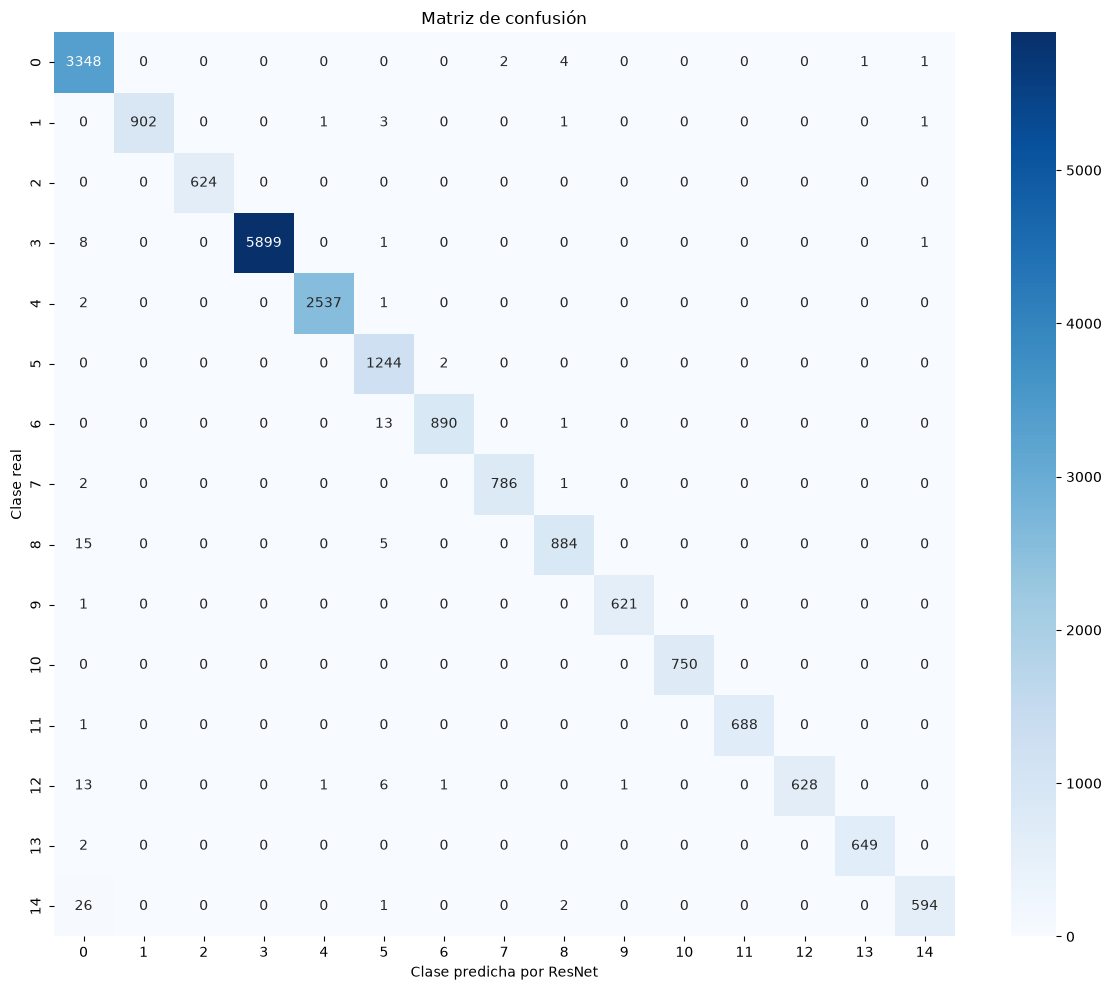

In [55]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
    #xticklabels=label_encoder.classes_,
    #yticklabels=label_encoder.classes_
)

plt.xlabel("Clase predicha por ResNet")
plt.ylabel("Clase real")
plt.title("Matriz de confusión")

plt.tight_layout()
plt.savefig("Matriz_confusion_ResNet.jpg")

plt.show()

## Validación local y migración del entrenamiento completo a Google Colab

El desarrollo del pipeline de Deep Learning se realizó inicialmente en entorno local mediante Jupyter Notebook.

En este entorno se validaron correctamente los pasos fundamentales del proceso:

- carga de los archivos CSV;
- corrección y verificación de rutas de imágenes;
- creación de generadores;
- carga de ResNet50 preentrenada;
- adaptación del modelo a las 15 clases del proyecto;
- compilación del modelo;
- ejecución de entrenamientos parciales y controlados.

Estas ejecuciones parciales permitieron comprobar que el pipeline funcionaba correctamente a nivel técnico y que el modelo era capaz de aprender sobre el dataset.

No obstante, al intentar ejecutar el entrenamiento completo en el equipo local, se detectaron limitaciones del entorno, especialmente relacionadas con la carga sostenida de CPU, la estabilidad del equipo y la ausencia de GPU dedicada.

Por este motivo, se decidió migrar el entrenamiento completo a Google Colab con GPU, manteniendo la misma lógica metodológica del notebook y utilizando el entorno local como fase de validación y preparación del pipeline.